## Part 1 - Cell 1: Imports


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay

import itertools
import time
from tqdm import tqdm
from collections import defaultdict


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


# Part 1 - Cell 2: Load dataset

In [3]:
df = pd.read_csv("../../datasets/raw/diabetes_structured.csv")

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Part 1 - Cell 3: Basic Info


In [4]:
print("Info:")
print(df.info())

print("\nDescriptive Statistics:")
df.describe().T


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Part 1 - Cell 4: Check missing-like values (zeros)


In [5]:
cols_with_zero_as_nan = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Number of zeros in critical columns:")
(df[cols_with_zero_as_nan] == 0).sum()


Number of zeros in critical columns:


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

# Part 1 - Cell 5: Replace zeros with NaN


In [6]:
df_clean = df.copy()
df_clean[cols_with_zero_as_nan] = df_clean[cols_with_zero_as_nan].replace(0, np.nan)

df_clean.isna().sum()


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Part 1 - Cell 6: Missing Value Visualization

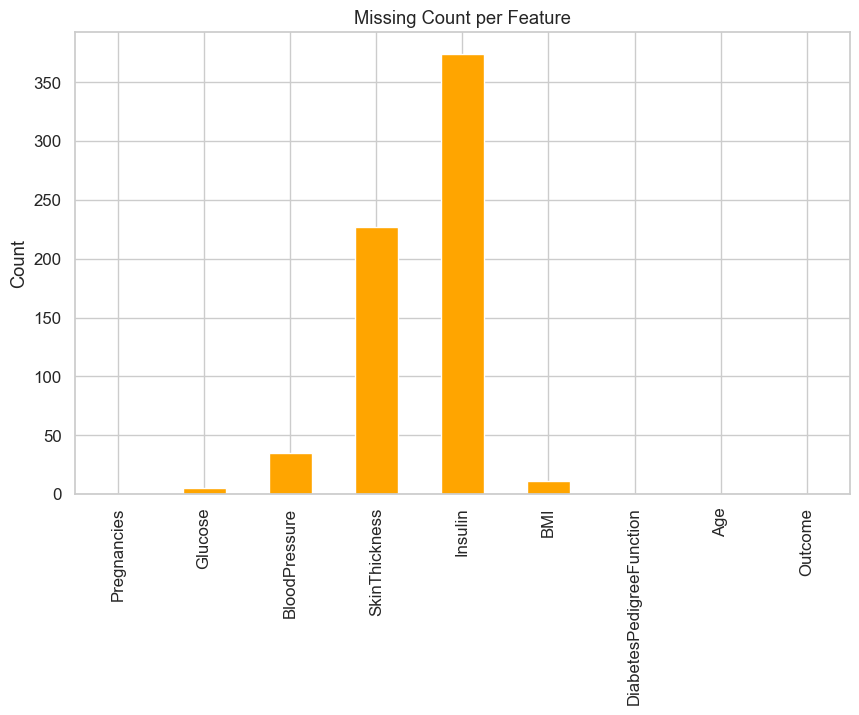

In [7]:
# Bar plot
ax = df_clean.isna().sum().plot(kind="bar", color="orange")
ax.set_title("Missing Count per Feature")
ax.set_ylabel("Count")

plt.show()


# Part 1 - Cell 7: Imputation


In [8]:
imputer = SimpleImputer(strategy="median")
df_clean[cols_with_zero_as_nan] = imputer.fit_transform(df_clean[cols_with_zero_as_nan])

df_clean.isna().sum() 


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Part 1 - Cell 8: Post-cleaning describe


In [9]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.108073,8.791221,7.000,25.00000,29.0000,32.00000,99.00
Insulin,768.0,140.671875,86.383060,14.000,121.50000,125.0000,127.25000,846.00
BMI,768.0,32.455208,6.875177,18.200,27.50000,32.3000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# Part 1 - Cell 9: Overall Distribution

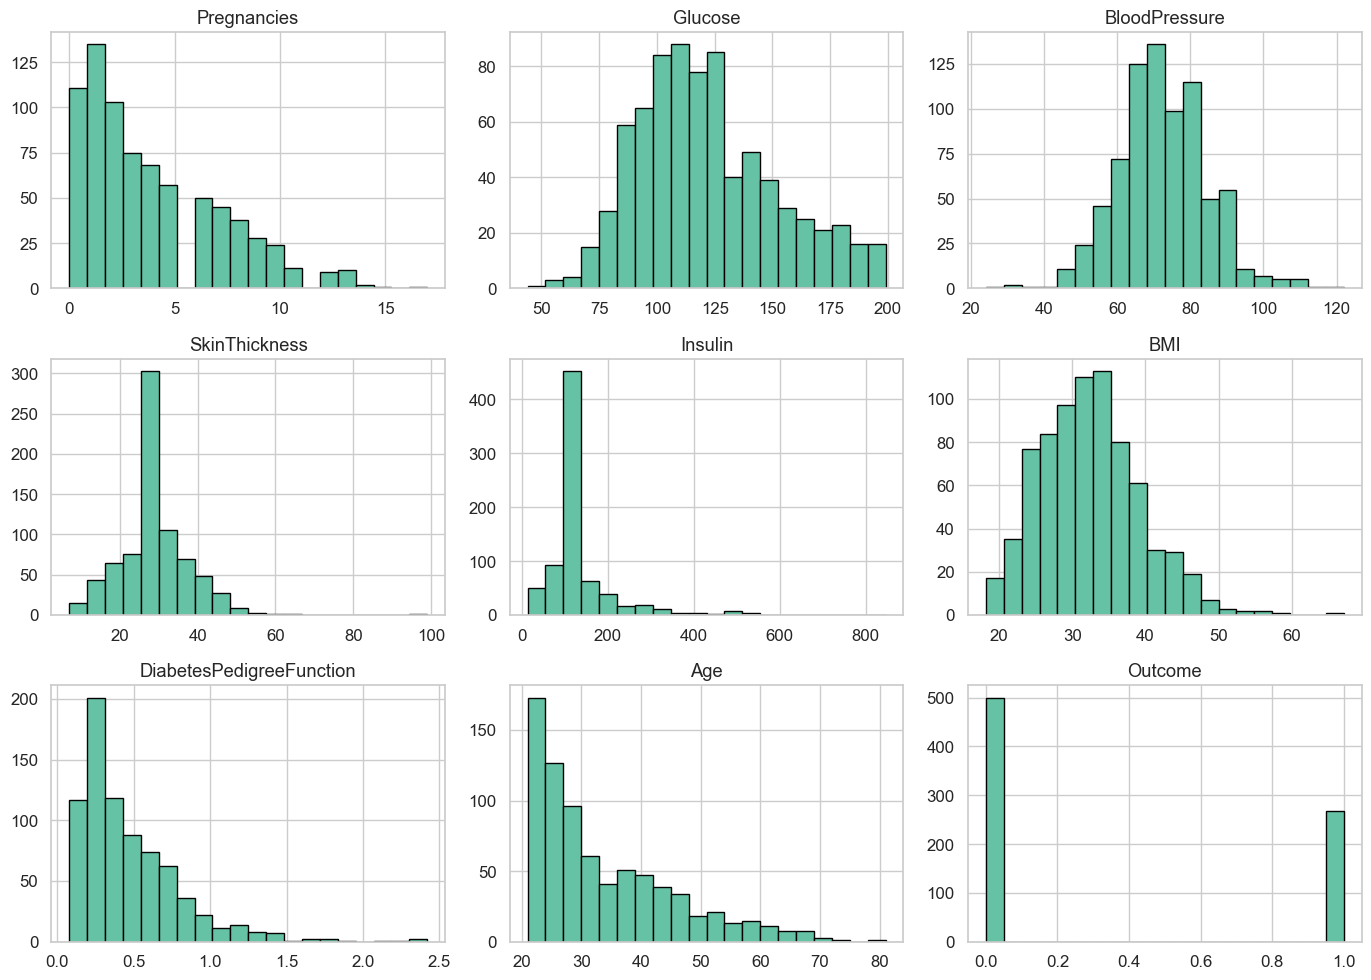

In [10]:
df_clean.hist(figsize=(14, 10), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


# -----------------------------
# Part 1 - Cell 10: Correlation Heatmap
# -----------------------------


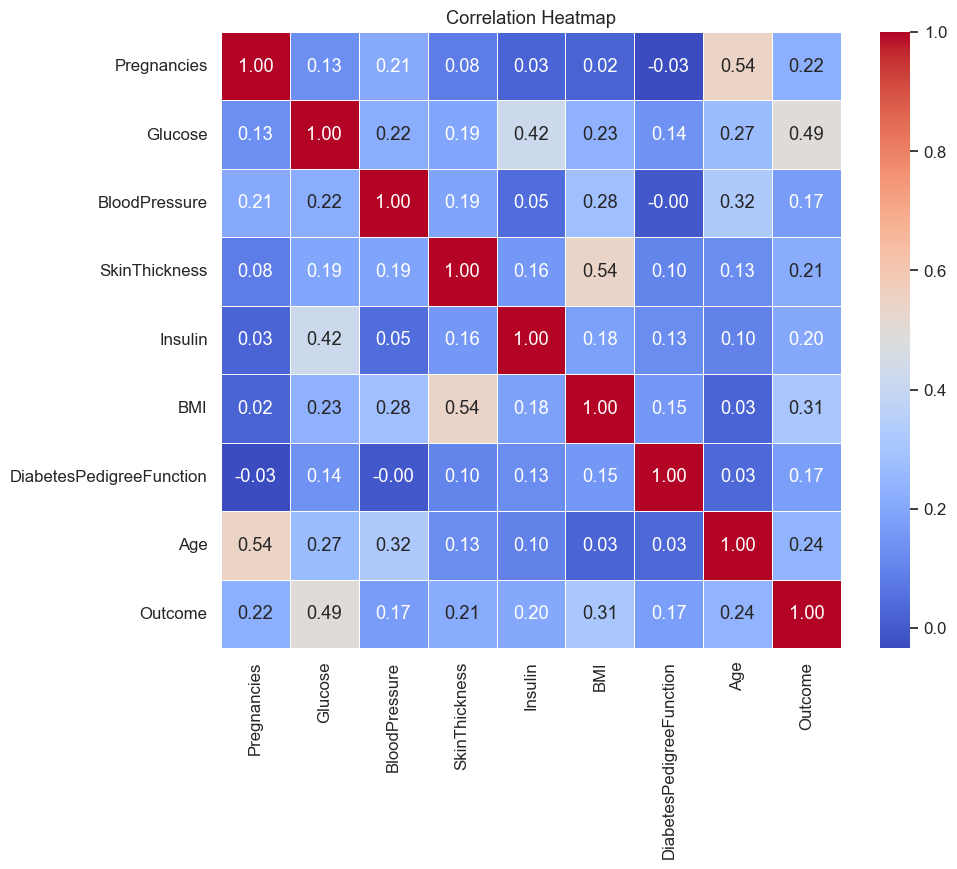

In [11]:
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


# -----------------------------
# Part 1 - Cell 11: Outcome Distribution
# -----------------------------


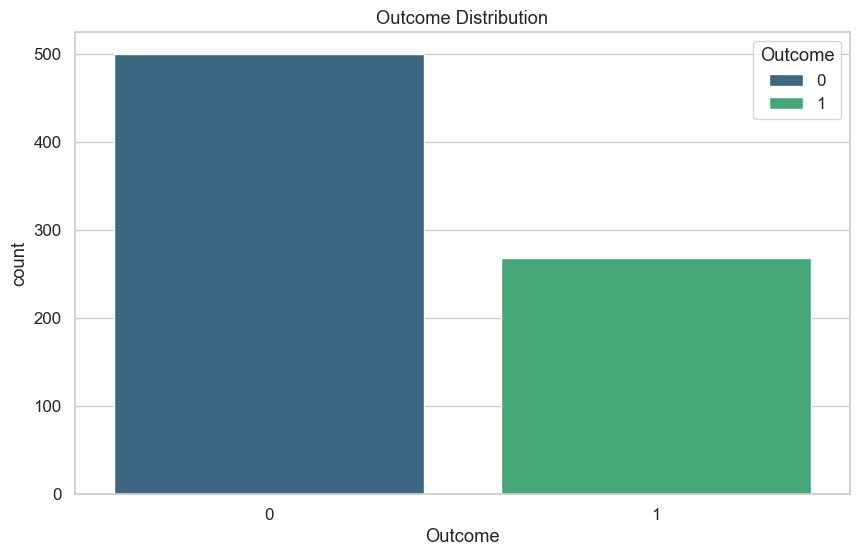

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [12]:
sns.countplot(data=df_clean, x="Outcome", hue="Outcome", palette="viridis")
plt.title("Outcome Distribution")
plt.show()

df_clean["Outcome"].value_counts(normalize=True) * 100


# -----------------------------
# Part 1 - Cell 12: Pairplot
# -----------------------------

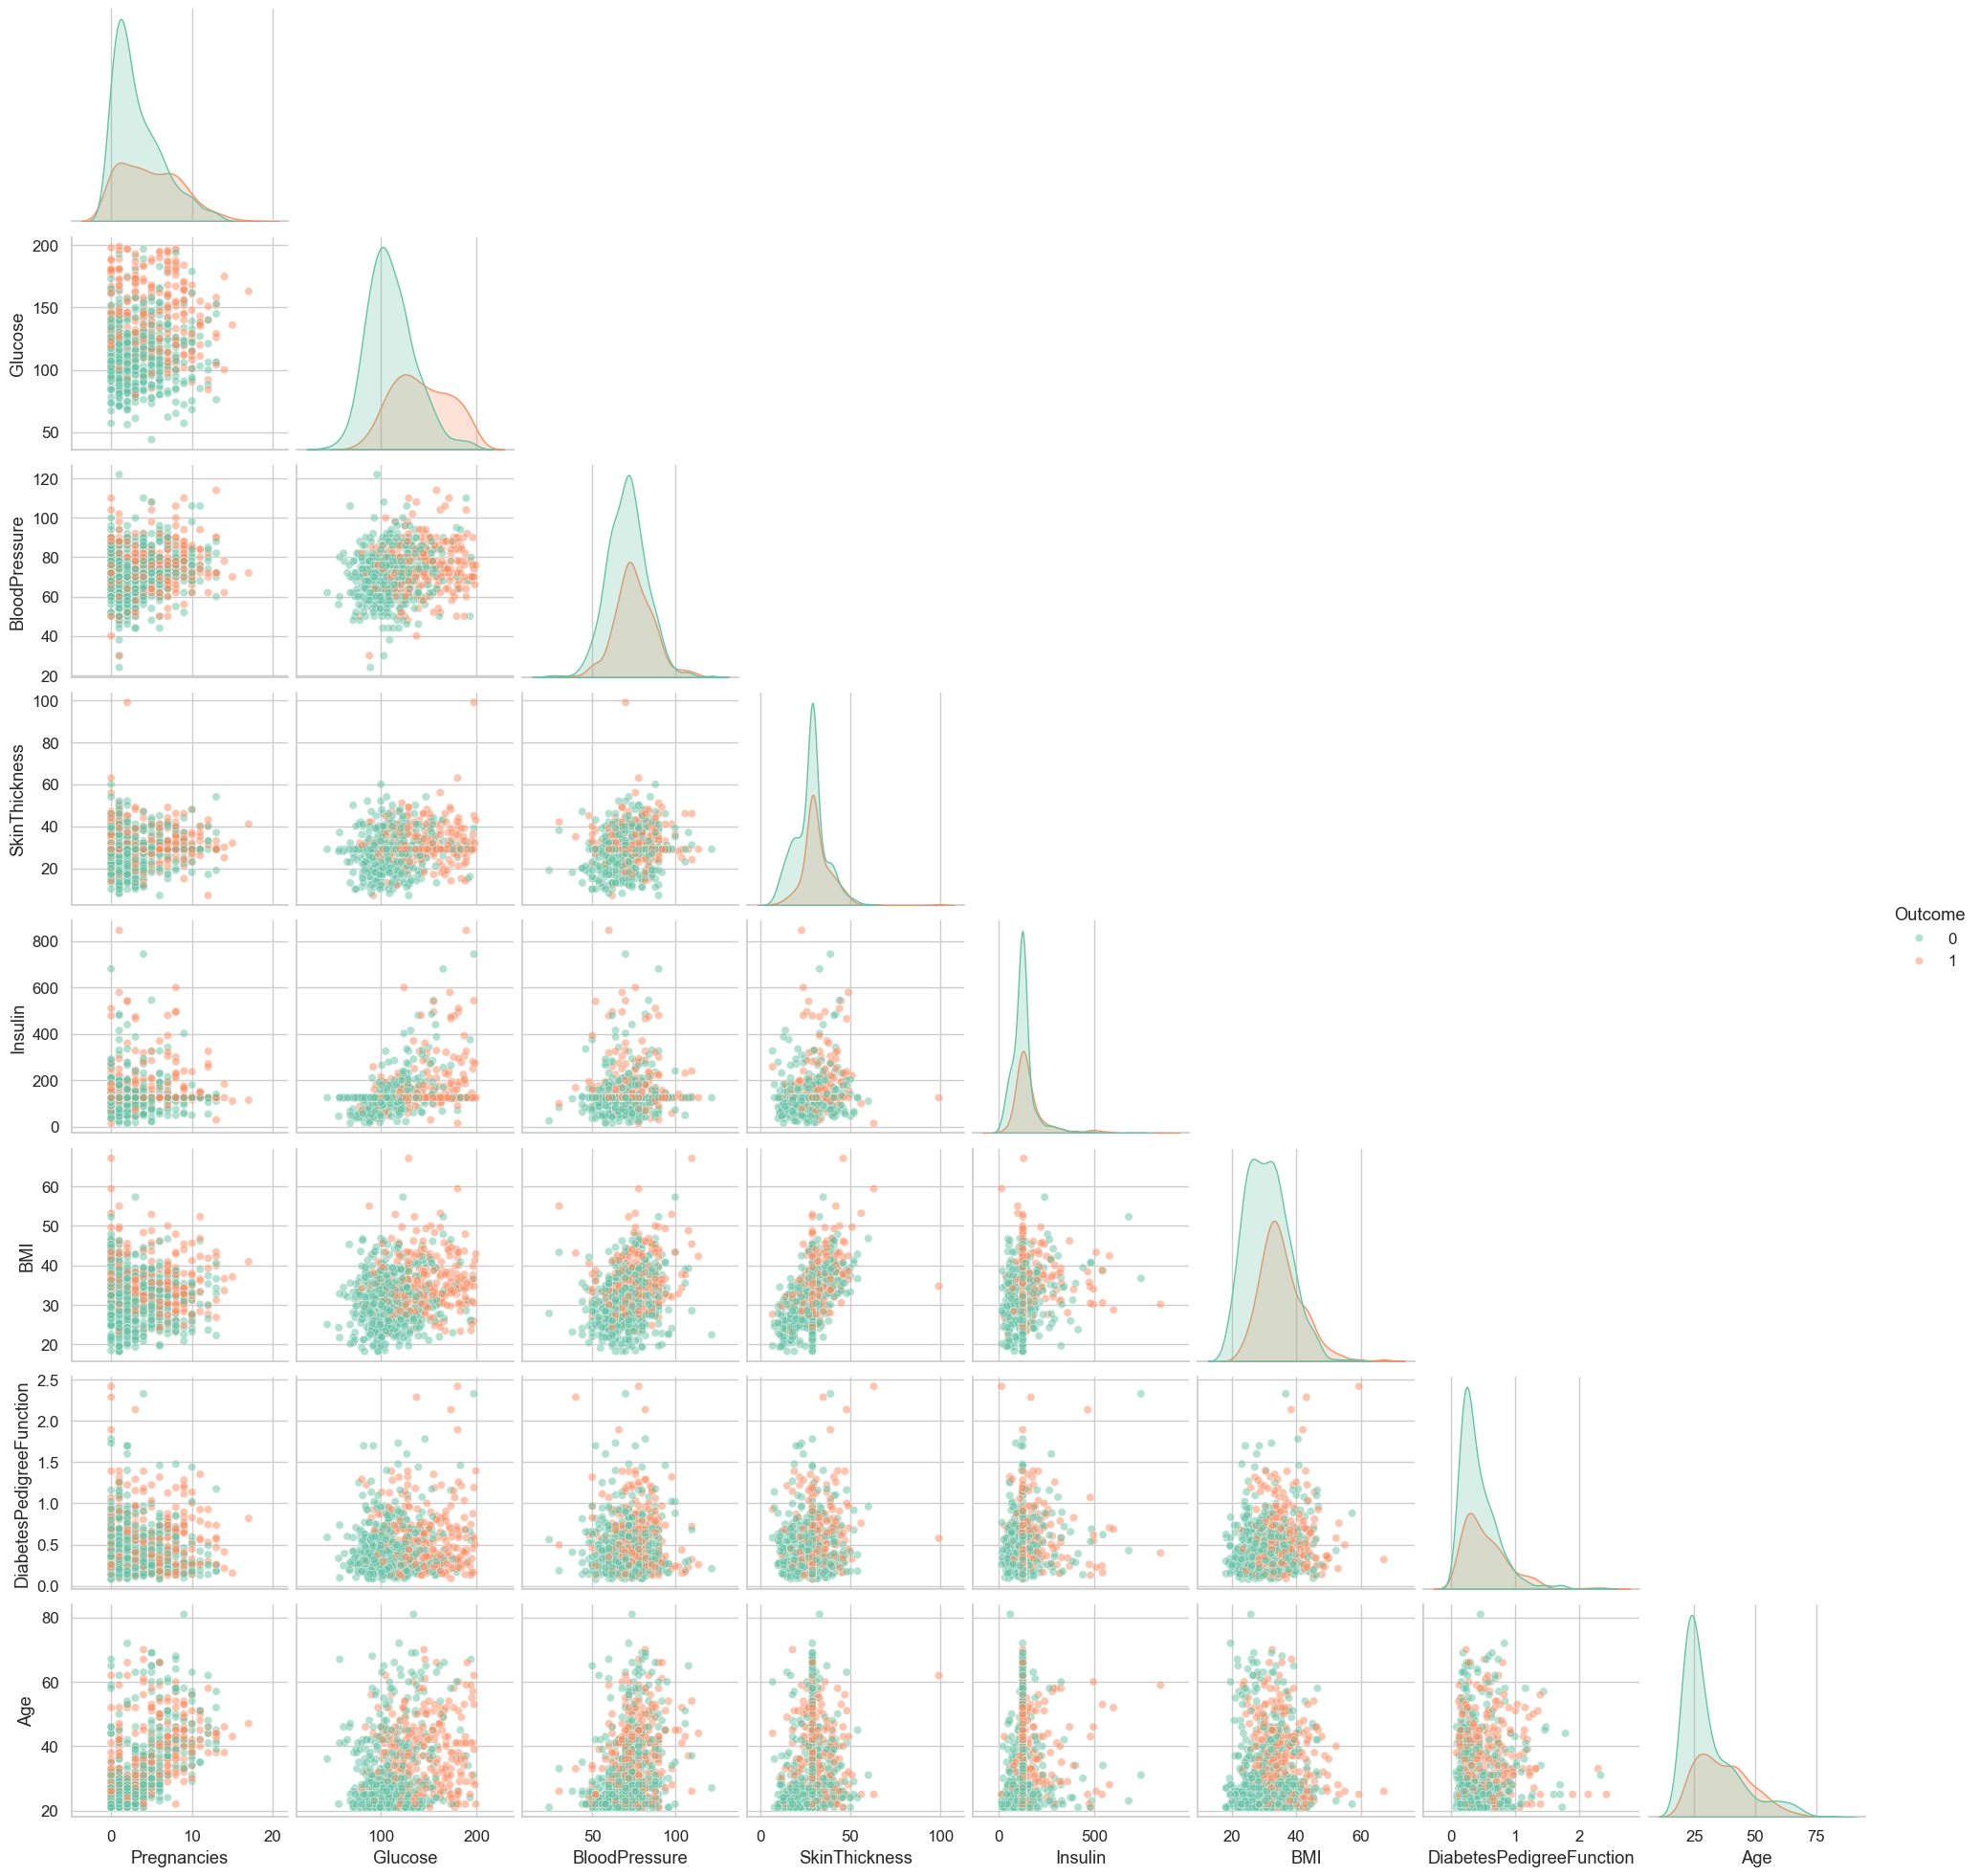

In [13]:
sns.pairplot(
    df_clean,
    hue="Outcome",
    diag_kind="kde",
    plot_kws={"alpha": 0.5},
    corner=True,
)
plt.show()


# -----------------------------
# Part 2 - Cell 1: Train/Val/Test Split
# -----------------------------


In [14]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# 60% train, 20% validation, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (460, 8)
Validation shape: (154, 8)
Test shape: (154, 8)


# -----------------------------
# Part 2 - Cell 2: Non-normalized datasets
# -----------------------------


In [15]:
X_train_raw = X_train.copy()
X_val_raw   = X_val.copy()
X_test_raw  = X_test.copy()

print("Raw dataset ready.")


Raw dataset ready.


# -----------------------------
# Part 2 - Cell 3: Normalized datasets
# -----------------------------


In [16]:
scaler = StandardScaler()

X_train_norm = scaler.fit_transform(X_train)
X_val_norm   = scaler.transform(X_val)
X_test_norm  = scaler.transform(X_test)

print("Normalized dataset ready.")


Normalized dataset ready.


# -----------------------------
# Part 2 - Cell 4: Statistical Comparison
# -----------------------------


In [17]:

print("Raw Train Describe:")
display(pd.DataFrame(X_train_raw).describe().T)

print("\nNormalized Train Describe:")
display(pd.DataFrame(X_train_norm, columns=X_train.columns).describe().T)


Raw Train Describe:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,460.0,3.867391,3.307386,0.000,1.0000,3.0000,6.0000,13.000
Glucose,460.0,121.191304,30.452405,57.000,99.0000,116.0000,139.2500,198.000
BloodPressure,460.0,72.143478,12.494054,24.000,64.0000,72.0000,80.0000,122.000
SkinThickness,460.0,28.882609,8.333158,7.000,26.0000,29.0000,32.0000,60.000
Insulin,460.0,136.110870,77.990214,16.000,120.0000,125.0000,126.7500,744.000
BMI,460.0,32.500435,6.797010,18.200,27.8000,32.3000,36.3250,67.100
DiabetesPedigreeFunction,460.0,0.481172,0.344756,0.084,0.2445,0.3825,0.6295,2.329
Age,460.0,33.306522,11.633265,21.000,24.0000,29.0000,40.0000,81.000



Normalized Train Describe:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,460.0,-1.737740e-17,1.001089,-1.170593,-0.867910,-0.262544,0.645504,2.764283
Glucose,460.0,-1.110223e-16,1.001089,-2.110217,-0.729514,-0.170658,0.593659,2.525000
BloodPressure,460.0,-4.933252e-16,1.001089,-3.857507,-0.652498,-0.011496,0.629505,3.994765
SkinThickness,460.0,7.723291e-17,1.001089,-2.628827,-0.346297,0.014103,0.374502,3.738231
Insulin,460.0,-1.004028e-16,1.001089,-1.541753,-0.206800,-0.142620,-0.120157,7.802914
BMI,460.0,-6.564797e-16,1.001089,-2.106221,-0.692297,-0.029521,0.563296,5.095952
DiabetesPedigreeFunction,460.0,5.502845e-17,1.001089,-1.153293,-0.687239,-0.286519,0.430710,5.365657
Age,460.0,2.442491e-16,1.001089,-1.059025,-0.800863,-0.370593,0.576000,4.104214


# -----------------------------
# Part 2 - Cell 5: Visualization of Normalization Effect
# -----------------------------


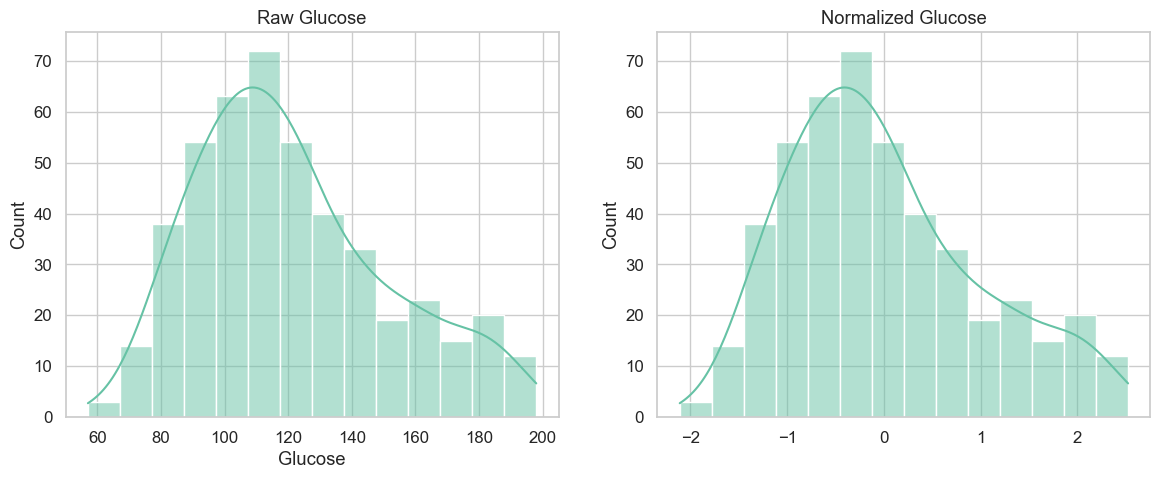

In [18]:
feature = "Glucose"

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(X_train_raw[feature], kde=True, ax=ax[0])
ax[0].set_title(f"Raw {feature}")

sns.histplot(pd.Series(X_train_norm[:, X_train.columns.get_loc(feature)]), kde=True, ax=ax[1])
ax[1].set_title(f"Normalized {feature}")

plt.show()


# -----------------------------
# Part 2 - Cell 7: Save prepared splits 
# -----------------------------


In [19]:
train_data = pd.concat([X_train_raw, y_train], axis=1)
val_data   = pd.concat([X_val_raw, y_val], axis=1)
test_data  = pd.concat([X_test_raw, y_test], axis=1)

train_data.to_csv("train_raw.csv", index=False)
val_data.to_csv("val_raw.csv", index=False)
test_data.to_csv("test_raw.csv", index=False)

print("Saved raw datasets.")

# Normalized
np.save("X_train_norm.npy", X_train_norm)
np.save("X_val_norm.npy",   X_val_norm)
np.save("X_test_norm.npy",  X_test_norm)

y_train.to_csv("y_train.csv", index=False)
y_val.to_csv("y_val.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved normalized datasets.")


Saved raw datasets.
Saved normalized datasets.


# -----------------------------
# Part 3 - Cell 1: reproducibility
# -----------------------------

In [20]:
# reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

sns.set(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)

# -----------------------------
# Part 3 - Cell 2: Model builder and train function
# -----------------------------

In [21]:
def build_model(input_dim, n_layers=1, n_units=16, activation="relu", dropout=0.0, l2_reg=0.0, learning_rate=1e-3):
    model = keras.Sequential()
    # Input layer
    model.add(layers.InputLayer(input_shape=(input_dim,)))
    for i in range(n_layers):
        model.add(layers.Dense(n_units, activation=activation,
                               kernel_regularizer=regularizers.l2(l2_reg)))
        # small dropout to reduce overfitting potential
        if dropout>0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

def train_model(model, X_tr, y_tr, X_val, y_val, epochs=100, batch_size=32, verbose=0):
    es = callbacks.EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True, verbose=0)
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[es],
        verbose=verbose
    )
    return history


# -----------------------------
# Part 3 - Cell 3: Define architecture grid
# -----------------------------

In [23]:
# We'll vary number of layers and units per layer. To keep grid manageable we use:
n_layers_list = [1, 2, 3]
n_units_list  = [8, 16, 32, 64]

# hyperparams fixed for these experiments:
dropout = 0.0
l2_reg = 0.0
learning_rate = 1e-3
batch_size = 32
epochs = 100

# create list of configurations
arch_configs = []
for nl in n_layers_list:
    for nu in n_units_list:
        arch_configs.append({"n_layers": nl, "n_units": nu})
len(arch_configs)


12

# -----------------------------
# Part 3 - Cell 5: Grid evaluation function
# -----------------------------

In [24]:
def evaluate_grid(X_tr, y_tr, X_val, y_val, configs, label="dataset", verbose=0):
    """
    For each config in configs, build model, train, evaluate AUC on validation.
    Returns: results list of dicts and a dict mapping config->history
    """
    results = []
    histories = {}
    input_dim = X_tr.shape[1]
    for cfg in configs:
        nl = cfg["n_layers"]
        nu = cfg["n_units"]
        cfg_name = f"layers{nl}_units{nu}"
        print(f"[{label}] Training {cfg_name} ...")
        model = build_model(input_dim=input_dim, n_layers=nl, n_units=nu,
                            dropout=dropout, l2_reg=l2_reg, learning_rate=learning_rate)
        start = time.time()
        hist = train_model(model, X_tr, y_tr, X_val, y_val, epochs=epochs, batch_size=batch_size, verbose=verbose)
        elapsed = time.time() - start
        # predict on val for AUC
        val_pred = model.predict(X_val).ravel()
        val_auc = roc_auc_score(y_val, val_pred)
        val_loss = hist.history["val_loss"][-1]
        val_acc = hist.history["val_accuracy"][-1]
        train_loss = hist.history["loss"][-1]
        train_acc = hist.history["accuracy"][-1]
        results.append({
            "config": cfg,
            "name": cfg_name,
            "val_auc": val_auc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "n_epochs": len(hist.history["loss"]),
            "time_s": elapsed,
            "history": hist
        })
        histories[cfg_name] = hist
    # sort by val_auc descending
    results_sorted = sorted(results, key=lambda x: x["val_auc"], reverse=True)
    return results_sorted, histories


# -----------------------------
# Part 3 - Cell 5: Run grid on normalized dataset
# -----------------------------

In [25]:
results_norm, histories_norm = evaluate_grid(
    X_train_norm, y_train.values, X_val_norm, y_val.values,
    arch_configs,
    label="Normalized",
    verbose=0
)

# Show top 5 configs
pd.DataFrame(results_norm)[:5][["name","val_auc","val_acc","val_loss","n_epochs","time_s"]]


[Normalized] Training layers1_units8 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[Normalized] Training layers1_units16 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[Normalized] Training layers1_units32 ...
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A3056B5090> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/ste

,name,val_auc,val_acc,val_loss,n_epochs,time_s
0,layers2_units64,0.863148,0.753247,0.463278,21,2.730567
1,layers2_units32,0.862407,0.772727,0.446477,27,3.696207
2,layers1_units32,0.861667,0.753247,0.452262,31,3.207654
3,layers3_units64,0.859074,0.753247,0.524423,15,2.662423
4,layers3_units32,0.855185,0.759740,0.492403,20,3.214044


# -----------------------------
# Part 3 - Cell 6: Run grid on raw (non-normalized) dataset
# -----------------------------

In [39]:
# but models expect numeric arrays -> convert
X_train_raw_arr = X_train_raw.values
X_val_raw_arr = X_val_raw.values
X_test_raw_arr = X_test_raw.values  # we'll need later

results_raw, histories_raw = evaluate_grid(
    X_train_raw_arr, y_train.values, X_val_raw_arr, y_val.values,
    arch_configs,
    label="Raw",
    verbose=0
)

# Show top 5 configs
pd.DataFrame(results_raw)[:5][["name","val_auc","val_acc","val_loss","n_epochs","time_s"]]


[Raw] Training layers1_units8 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[Raw] Training layers1_units16 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[Raw] Training layers1_units32 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[Raw] Training layers1_units64 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[Raw] Training layers2_units8 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[Raw] Training layers2_units16 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
[Raw] Training layers2_units32 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[Raw] Training layers2_units64 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[Raw] Training layers3_units8 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
[Raw] Training layers3_units16 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[Raw] Training layers3_units32 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[Raw] Training layers3_units64 ...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,name,val_auc,val_acc,val_loss,n_epochs,time_s
0,layers1_units64,0.754074,0.694805,0.578859,49,5.343947
1,layers2_units8,0.748889,0.701299,0.614026,100,11.304206
2,layers2_units32,0.747593,0.720779,0.618604,100,10.455723
3,layers3_units16,0.742963,0.714286,0.579641,81,8.906855
4,layers3_units8,0.736111,0.701299,0.580495,100,10.669059


# -----------------------------
# Part 3 - Cell 7: Heatmaps of validation AUC for quick visual comparison
# -----------------------------

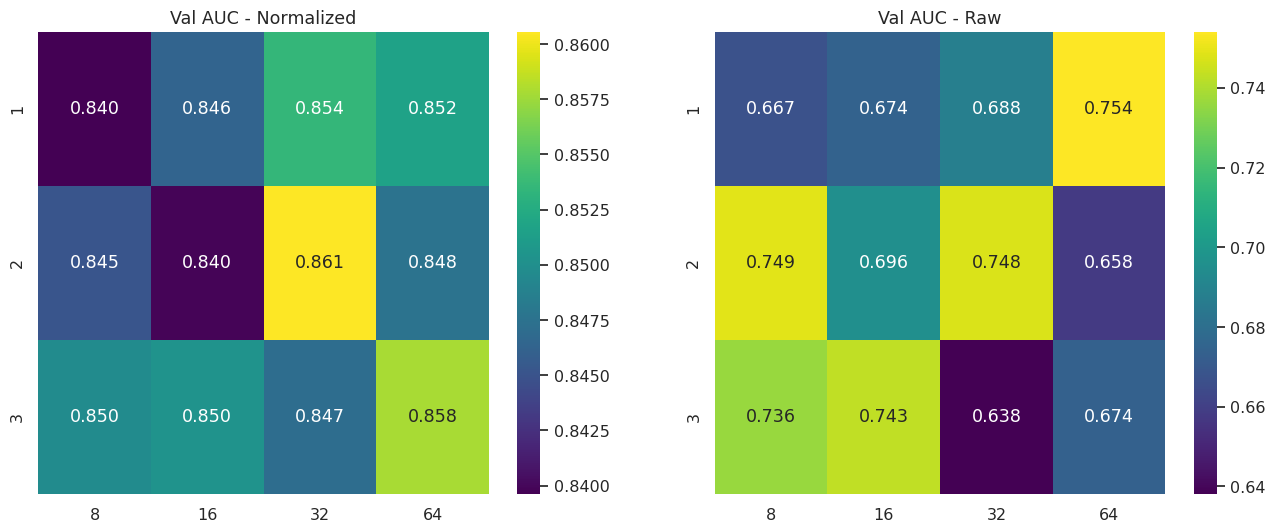

In [40]:
def results_to_matrix(results):
    # rows: n_layers, cols: n_units
    mat = pd.DataFrame(index=n_layers_list, columns=n_units_list, dtype=float)
    for r in results:
        nl = r["config"]["n_layers"]
        nu = r["config"]["n_units"]
        mat.loc[nl, nu] = r["val_auc"]
    return mat

mat_norm = results_to_matrix(results_norm)
mat_raw  = results_to_matrix(results_raw)

fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(mat_norm, annot=True, fmt=".3f", cmap="viridis", ax=ax[0])
ax[0].set_title("Val AUC - Normalized")
sns.heatmap(mat_raw, annot=True, fmt=".3f", cmap="viridis", ax=ax[1])
ax[1].set_title("Val AUC - Raw")
plt.show()


# -----------------------------
# Part 3 - Cell 8: Learning curves for representative models
# -----------------------------

Best normalized config: layers2_units32 val_auc= 0.8605555555555555


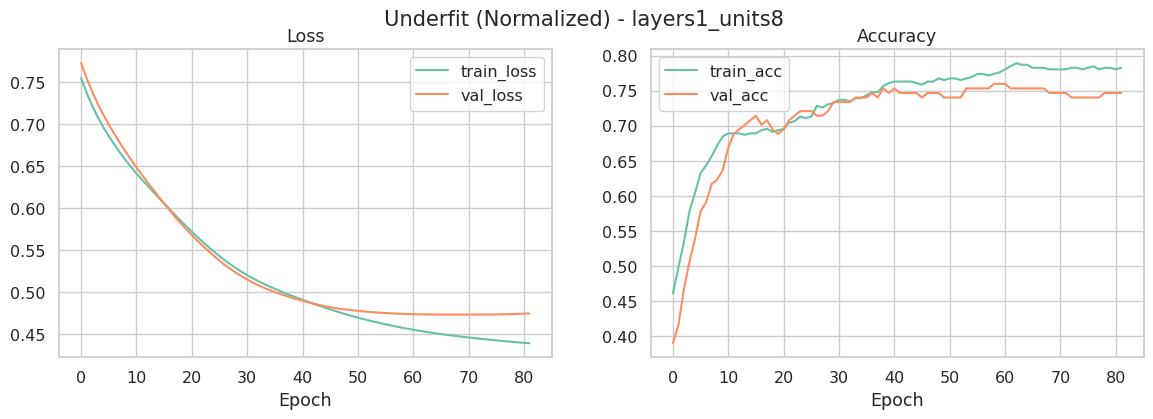

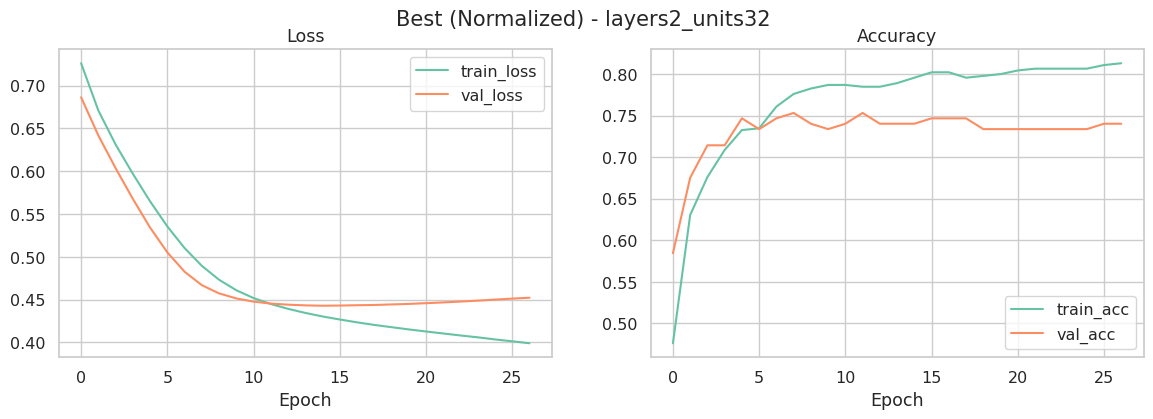

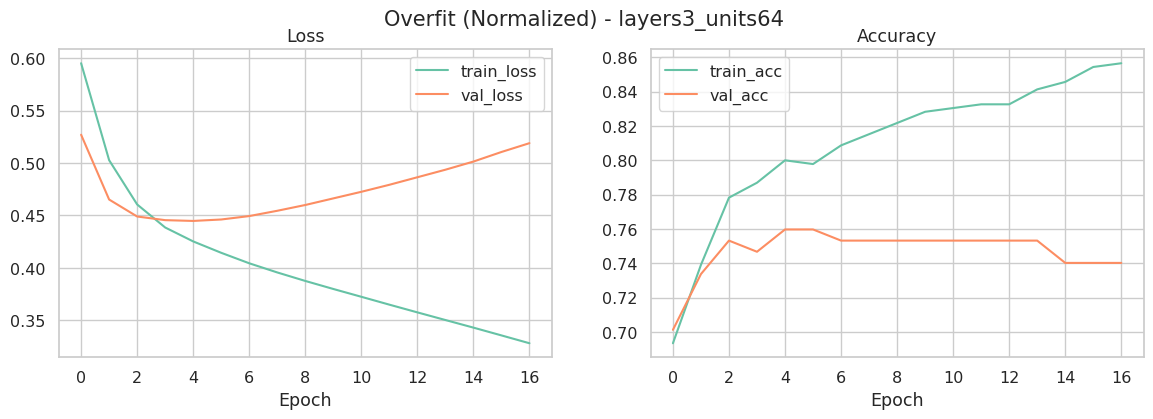

Best raw config: layers1_units64 val_auc= 0.7540740740740742


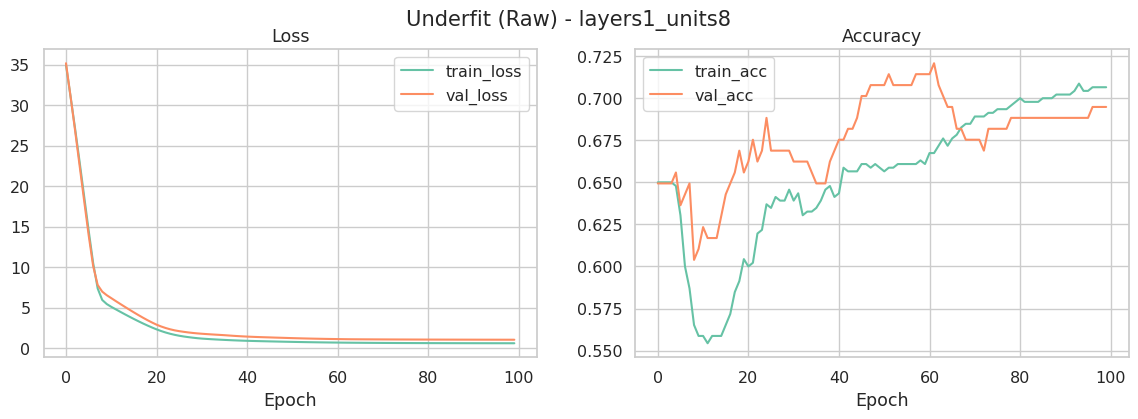

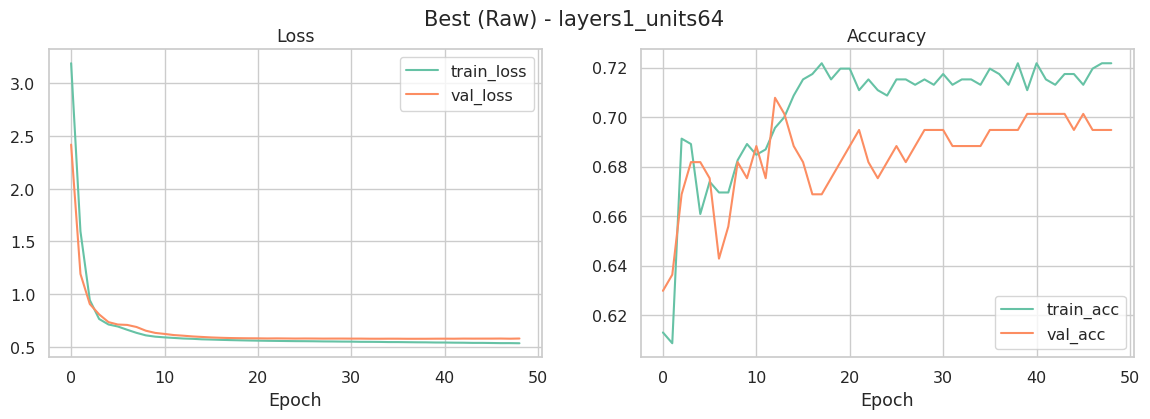

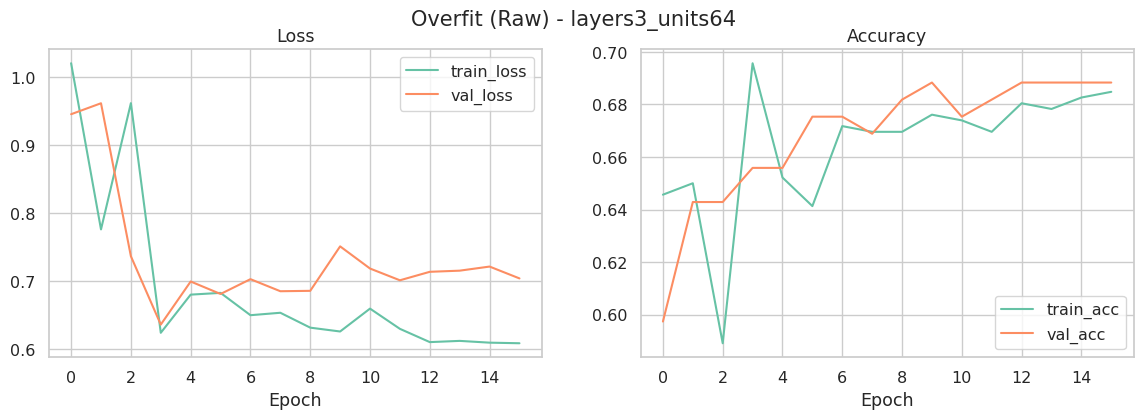

In [41]:

def plot_learning_curve_from_history(hist, title="Learning Curve"):
    # loss and accuracy
    fig, ax = plt.subplots(1,2, figsize=(14,4))
    ax[0].plot(hist.history["loss"], label="train_loss")
    ax[0].plot(hist.history["val_loss"], label="val_loss")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[0].set_xlabel("Epoch")

    ax[1].plot(hist.history["accuracy"], label="train_acc")
    ax[1].plot(hist.history["val_accuracy"], label="val_acc")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    ax[1].set_xlabel("Epoch")

    plt.suptitle(title)
    plt.show()

# select histories:
# Underfit (small)
hist_under_norm = histories_norm.get("layers1_units8")
hist_over_norm = histories_norm.get("layers3_units64")
# Good: top normalized config
best_norm_name = results_norm[0]["name"]
hist_best_norm = histories_norm.get(best_norm_name)

print("Best normalized config:", best_norm_name, "val_auc=", results_norm[0]["val_auc"])

# Plot them (normalized)
plot_learning_curve_from_history(hist_under_norm, title="Underfit (Normalized) - layers1_units8")
plot_learning_curve_from_history(hist_best_norm,  title=f"Best (Normalized) - {best_norm_name}")
plot_learning_curve_from_history(hist_over_norm,  title="Overfit (Normalized) - layers3_units64")

# Similarly for raw (if histories exist)
hist_under_raw = histories_raw.get("layers1_units8")
hist_over_raw = histories_raw.get("layers3_units64")
best_raw_name = results_raw[0]["name"]
hist_best_raw = histories_raw.get(best_raw_name)
print("Best raw config:", best_raw_name, "val_auc=", results_raw[0]["val_auc"])

plot_learning_curve_from_history(hist_under_raw, title="Underfit (Raw) - layers1_units8")
plot_learning_curve_from_history(hist_best_raw,  title=f"Best (Raw) - {best_raw_name}")
plot_learning_curve_from_history(hist_over_raw,  title="Overfit (Raw) - layers3_units64")


# -----------------------------
# Part 3 - Cell 9: Pick best models and evaluate on test set
# -----------------------------

In [45]:
# Best normalized config
best_norm_cfg = results_norm[0]["config"]
best_norm_name = results_norm[0]["name"]
print("Best normalized:", best_norm_name, best_norm_cfg, "val_auc=", results_norm[0]["val_auc"])

# Best raw config
best_raw_cfg = results_raw[0]["config"]
best_raw_name = results_raw[0]["name"]
print("Best raw:", best_raw_name, best_raw_cfg, "val_auc=", results_raw[0]["val_auc"])

# Re-train best models on train+val combined (optional) or use prior weights (we only have model histories)
# For a fair final evaluation we retrain on train+val combined for each best architecture, then test on test set.

def retrain_and_evaluate(cfg, X_train_comb, y_train_comb, X_test_arr, y_test_arr, label="Model"):
    nl = cfg["n_layers"]; nu = cfg["n_units"]
    model = build_model(input_dim=X_train_comb.shape[1], n_layers=nl, n_units=nu,
                        dropout=dropout, l2_reg=l2_reg, learning_rate=learning_rate)
    hist = train_model(model, X_train_comb, y_train_comb, X_val=X_train_comb, y_val=y_train_comb, epochs=epochs, batch_size=batch_size, verbose=0)
    # predict on test
    pred_proba = model.predict(X_test_arr).ravel()
    pred_label = (pred_proba >= 0.5).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_test_arr, pred_label),
        "precision": precision_score(y_test_arr, pred_label, zero_division=0),
        "recall": recall_score(y_test_arr, pred_label, zero_division=0),
        "f1": f1_score(y_test_arr, pred_label, zero_division=0),
        "roc_auc": roc_auc_score(y_test_arr, pred_proba)
    }
    fpr, tpr, _ = roc_curve(y_test_arr, pred_proba)
    return model, hist, metrics, (fpr, tpr)

# prepare train+val combined for normalized
X_trval_norm = np.vstack([X_train_norm, X_val_norm])
y_trval = np.concatenate([y_train.values, y_val.values])

# prepare train+val combined for raw
X_trval_raw = np.vstack([X_train_raw.values, X_val_raw.values])

# Evaluate best normalized
model_norm_best, hist_norm_best, metrics_norm_best, roc_norm = retrain_and_evaluate(best_norm_cfg, X_trval_norm, y_trval, X_test_norm, y_test.values, label="BestNormal")

# Evaluate best raw
model_raw_best, hist_raw_best, metrics_raw_best, roc_raw = retrain_and_evaluate(best_raw_cfg, X_trval_raw, y_trval, X_test_raw_arr, y_test.values, label="BestRaw")

print("Metrics (Normalized best) on TEST:", metrics_norm_best)
print("Metrics (Raw best) on TEST:", metrics_raw_best)


Best normalized: layers2_units32 {'n_layers': 2, 'n_units': 32} val_auc= 0.8605555555555555
Best raw: layers1_units64 {'n_layers': 1, 'n_units': 64} val_auc= 0.7540740740740742
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Metrics (Normalized best) on TEST: {'accuracy': 0.6948051948051948, 'precision': 0.575, 'recall': 0.4339622641509434, 'f1': 0.49462365591397855, 'roc_auc': 0.7803101064823463}
Metrics (Raw best) on TEST: {'accuracy': 0.6688311688311688, 'precision': 0.5384615384615384, 'recall': 0.2641509433962264, 'f1': 0.3544303797468354, 'roc_auc': 0.7263216887726508}


# Part 3 - Cell 10: ROC curves comparison


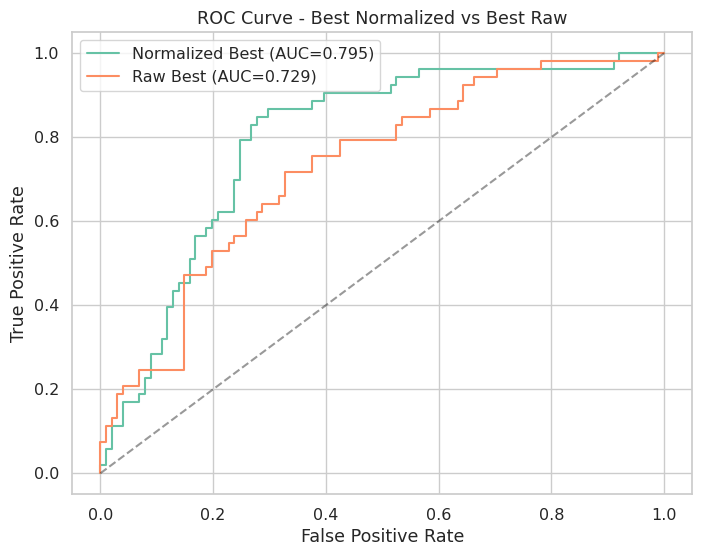

In [43]:
fpr_n, tpr_n = roc_norm
fpr_r, tpr_r = roc_raw

plt.figure(figsize=(8,6))
plt.plot(fpr_n, tpr_n, label=f"Normalized Best (AUC={metrics_norm_best['roc_auc']:.3f})")
plt.plot(fpr_r, tpr_r, label=f"Raw Best (AUC={metrics_raw_best['roc_auc']:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Normalized vs Best Raw")
plt.legend()
plt.show()


# -----------------------------
# Part 3 - Cell 12: Summary table of best configs and metrics
# -----------------------------

In [44]:

summary = pd.DataFrame([
    {"type":"Normalized", "config": best_norm_name, "val_auc": results_norm[0]["val_auc"], **metrics_norm_best},
    {"type":"Raw",        "config": best_raw_name,  "val_auc": results_raw[0]["val_auc"],  **metrics_raw_best}
])
display(summary)


,type,config,val_auc,accuracy,precision,recall,f1,roc_auc
0,Normalized,layers2_units32,0.860556,0.727273,0.612245,0.566038,0.588235,0.795068
1,Raw,layers1_units64,0.754074,0.675325,0.565217,0.245283,0.342105,0.729311


# -----------------------------
# Part 4 - Cell 1: model builder (base architecture: 2 layers x 32 units)
# -----------------------------

In [46]:
# reproducibility
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

def build_model_base(input_dim, n_layers=2, n_units=32, activation="relu", dropout=0.0, l2_reg=0.0, learning_rate=1e-3, optimizer_name="adam"):
    model = keras.Sequential()
    model.add(layers.InputLayer(input_shape=(input_dim,)))
    for i in range(n_layers):
        model.add(layers.Dense(n_units, activation=activation,
                               kernel_regularizer=regularizers.l2(l2_reg)))
        if dropout>0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    if optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == "rmsprop":
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name.lower() == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return model

def evaluate_on_val(model, X_val, y_val):
    pred = model.predict(X_val).ravel()
    auc = roc_auc_score(y_val, pred)
    return auc, pred


# -----------------------------
# Part 4 - Cell 2: Hyperparameter grid (moderate size)
# -----------------------------

In [47]:
batch_sizes = [16, 32, 64]
learning_rates = [1e-2, 1e-3, 1e-4]
dropouts = [0.0, 0.2, 0.4]
l2_regs = [0.0, 1e-4, 1e-3]
optimizers = ["adam", "rmsprop", "sgd"]   

# fixed choices (architecture)
n_layers = 2
n_units = 32

# training control
epochs = 100
patience = 12


# -----------------------------
# Part 4 - Cell 3: Grid search 
# -----------------------------

In [48]:
results = []
input_dim = X_train_norm.shape[1]

total_runs = len(batch_sizes) * len(learning_rates) * len(dropouts) * len(l2_regs) * len(optimizers)
print("Total runs:", total_runs)

pbar = tqdm(total=total_runs)
for bs in batch_sizes:
    for lr in learning_rates:
        for dp in dropouts:
            for l2r in l2_regs:
                for opt_name in optimizers:
                    cfg = {"batch_size": bs, "learning_rate": lr, "dropout": dp, "l2_reg": l2r, "optimizer": opt_name}
                    # build
                    model = build_model_base(input_dim=input_dim, n_layers=n_layers, n_units=n_units,
                                             dropout=dp, l2_reg=l2r, learning_rate=lr, optimizer_name=opt_name)
                    # callbacks
                    es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0)
                    start = time.time()
                    history = model.fit(
                        X_train_norm, y_train.values,
                        validation_data=(X_val_norm, y_val.values),
                        epochs=epochs, batch_size=bs, callbacks=[es], verbose=0
                    )
                    elapsed = time.time() - start
                    val_auc, val_pred = evaluate_on_val(model, X_val_norm, y_val.values)
                    # store results
                    results.append({
                        "cfg": cfg,
                        "val_auc": val_auc,
                        "n_epochs": len(history.history["loss"]),
                        "time_s": elapsed,
                        "history": history,
                        "model": model  # caution: large memory if many models; consider saving only small number
                    })
                    pbar.update(1)
pbar.close()

# sort by val_auc
results_sorted = sorted(results, key=lambda x: x["val_auc"], reverse=True)
# show top 5
import pprint
for i, r in enumerate(results_sorted[:5]):
    print(f"Rank {i+1}: val_auc={r['val_auc']:.4f}, cfg={r['cfg']}, epochs={r['n_epochs']}, time_s={r['time_s']:.1f}")


Total runs: 243


  0%|          | 0/243 [00:00<?, ?it/s]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


  0%|          | 1/243 [00:03<12:30,  3.10s/it]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


100%|█████████▉| 242/243 [30:15<00:09,  9.27s/it]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


100%|██████████| 243/243 [30:24<00:00,  7.51s/it]

Rank 1: val_auc=0.8720, cfg={'batch_size': 16, 'learning_rate': 0.01, 'dropout': 0.0, 'l2_reg': 0.0, 'optimizer': 'sgd'}, epochs=49, time_s=7.0
Rank 2: val_auc=0.8709, cfg={'batch_size': 16, 'learning_rate': 0.001, 'dropout': 0.0, 'l2_reg': 0.001, 'optimizer': 'adam'}, epochs=23, time_s=3.9
Rank 3: val_auc=0.8693, cfg={'batch_size': 32, 'learning_rate': 0.001, 'dropout': 0.4, 'l2_reg': 0.0001, 'optimizer': 'adam'}, epochs=37, time_s=4.6
Rank 4: val_auc=0.8685, cfg={'batch_size': 16, 'learning_rate': 0.0001, 'dropout': 0.0, 'l2_reg': 0.0001, 'optimizer': 'rmsprop'}, epochs=99, time_s=13.1
Rank 5: val_auc=0.8683, cfg={'batch_size': 16, 'learning_rate': 0.01, 'dropout': 0.4, 'l2_reg': 0.0001, 'optimizer': 'adam'}, epochs=13, time_s=2.7


# -----------------------------
# Part 4 - Cell 4: Best config and its learning curve
# -----------------------------

Best cfg: {'batch_size': 16, 'learning_rate': 0.01, 'dropout': 0.0, 'l2_reg': 0.0, 'optimizer': 'sgd'}
Best val AUC: 0.872037037037037


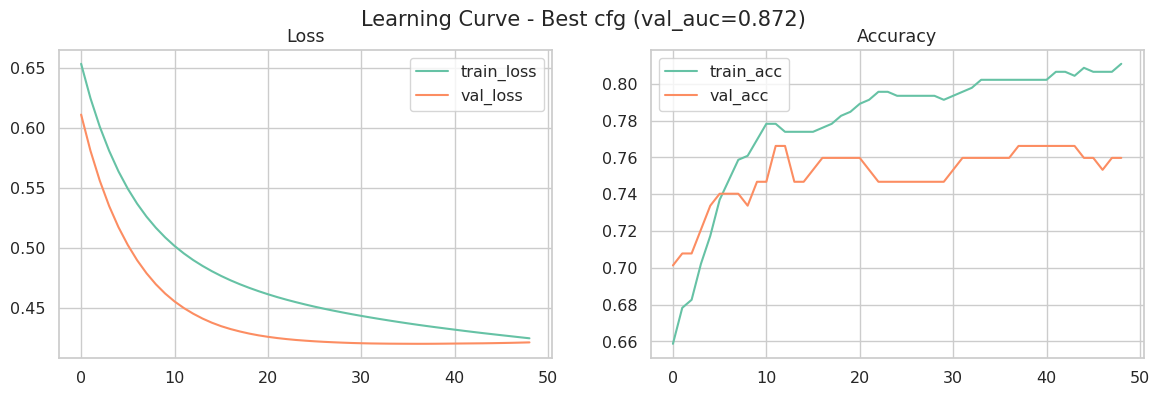

In [49]:
best = results_sorted[0]
best_cfg = best["cfg"]
best_val_auc = best["val_auc"]
best_model = best["model"]
best_history = best["history"]

print("Best cfg:", best_cfg)
print("Best val AUC:", best_val_auc)

# plot learning curve
hist = best_history.history
fig, ax = plt.subplots(1,2, figsize=(14,4))
ax[0].plot(hist["loss"], label="train_loss"); ax[0].plot(hist["val_loss"], label="val_loss"); ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(hist["accuracy"], label="train_acc"); ax[1].plot(hist["val_accuracy"], label="val_acc"); ax[1].set_title("Accuracy"); ax[1].legend()
plt.suptitle(f"Learning Curve - Best cfg (val_auc={best_val_auc:.3f})")
plt.show()


# -----------------------------
# Part 4 - Cell 5: Retrain best on train+val and evaluate on test
# -----------------------------

In [50]:
# Prepare combined data
X_trval = np.vstack([X_train_norm, X_val_norm])
y_trval = np.concatenate([y_train.values, y_val.values])

# Build model with best cfg
final_bs = best_cfg["batch_size"]
final_lr = best_cfg["learning_rate"]
final_dp = best_cfg["dropout"]
final_l2 = best_cfg["l2_reg"]
final_opt = best_cfg["optimizer"]

final_model = build_model_base(input_dim=input_dim, n_layers=n_layers, n_units=n_units,
                               dropout=final_dp, l2_reg=final_l2, learning_rate=final_lr, optimizer_name=final_opt)

es = callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=1)
# We can use a small validation split during retraining or none (but keep a tiny split to let ES work)
hist_final = final_model.fit(X_trval, y_trval, validation_split=0.1, epochs=200, batch_size=final_bs, callbacks=[es], verbose=1)

# Evaluate on test
pred_proba_test = final_model.predict(X_test_norm).ravel()
pred_label_test = (pred_proba_test >= 0.5).astype(int)

metrics_test = {
    "accuracy": accuracy_score(y_test.values, pred_label_test),
    "precision": precision_score(y_test.values, pred_label_test, zero_division=0),
    "recall": recall_score(y_test.values, pred_label_test, zero_division=0),
    "f1": f1_score(y_test.values, pred_label_test, zero_division=0),
    "roc_auc": roc_auc_score(y_test.values, pred_proba_test)
}
print("Final Test Metrics:", metrics_test)


Epoch 1/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5442 - loss: 0.6790 - val_accuracy: 0.6290 - val_loss: 0.6842
Epoch 2/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7180 - loss: 0.6321 - val_accuracy: 0.6452 - val_loss: 0.6484
Epoch 3/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7395 - loss: 0.5968 - val_accuracy: 0.6935 - val_loss: 0.6209
Epoch 4/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7547 - loss: 0.5690 - val_accuracy: 0.6935 - val_loss: 0.5990
Epoch 5/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7621 - loss: 0.5465 - val_accuracy: 0.6935 - val_loss: 0.5815
Epoch 6/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7652 - loss: 0.5284 - val_accuracy: 0.6935 - val_loss: 0.5676
Epoch 7/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7701 - loss: 0.5141 - val_accuracy: 0.7097 - val_loss: 0.5565
Epoch 8/200
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7669 - loss: 0.5025 - val_accuracy: 0.7097 - v

# -----------------------------
# Part 4 - Cell 6: ROC and Confusion Matrix
# -----------------------------

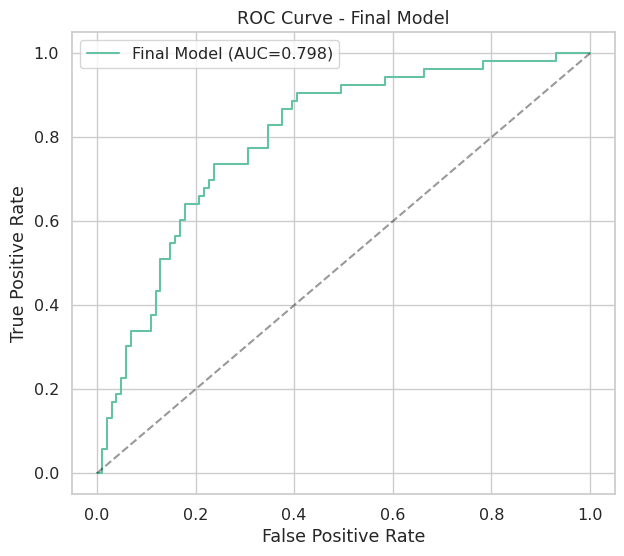

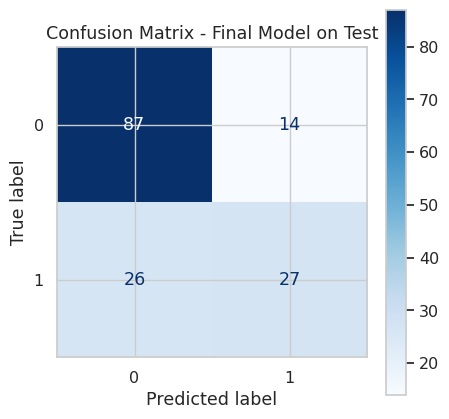

In [51]:
# ROC
fpr, tpr, _ = roc_curve(y_test.values, pred_proba_test)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Final Model (AUC={metrics_test['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Model")
plt.legend()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test.values, pred_label_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Final Model on Test")
plt.show()


# -----------------------------
# Part 4 - Cell 7: Save best model
# -----------------------------

In [54]:
# Save full model in the new recommended Keras format
final_model.save("best_model.keras")

# Save architecture as JSON
model_json = final_model.to_json()
with open("best_model_architecture.json", "w") as f:
    f.write(model_json)

# Save weights in the new required format
final_model.save_weights("best_model.weights.h5")

print("Saved: best_model.keras, best_model_architecture.json, best_model.weights.h5")


Saved: best_model.keras, best_model_architecture.json, best_model.weights.h5


# -----------------------------
# Part 4 - Cell 8: Summary table
# -----------------------------

In [52]:
summary = {
    "chosen_dataset": "Normalized",
    "base_architecture": f"layers={n_layers}, units={n_units}",
    "best_cfg": best_cfg,
    "val_auc": best_val_auc,
    "test_metrics": metrics_test
}
import pprint
pprint.pprint(summary)


{'base_architecture': 'layers=2, units=32',
 'best_cfg': {'batch_size': 16,
              'dropout': 0.0,
              'l2_reg': 0.0,
              'learning_rate': 0.01,
              'optimizer': 'sgd'},
 'chosen_dataset': 'Normalized',
 'test_metrics': {'accuracy': 0.7402597402597403,
                  'f1': 0.574468085106383,
                  'precision': 0.6585365853658537,
                  'recall': 0.5094339622641509,
                  'roc_auc': 0.7978703530730431},
 'val_auc': 0.872037037037037}
